In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, round as spark_round

spark = SparkSession.builder \
    .appName("PISA-Global-Analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.4.0") \
    .getOrCreate()

In [3]:
from pyspark.sql.functions import col, avg, round as spark_round, lit

def get_global_stats(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # 1. Chosen ICT columns
    ict_col = "ICTAVHOM_SUM" if year == 2012 else "ICTAVHOM"
    
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    clean_df = df.select("PV1MATH", "PV1READ", ict_col, "CNT") \
                 .filter(
                     col("PV1MATH").isNotNull() & 
                     col(ict_col).isNotNull()
                 )
    
    # Counting averages for math, reading, and ICT
    averages = clean_df.select(
        spark_round(avg("PV1MATH"), 2).alias("avg_math"),
        spark_round(avg("PV1READ"), 2).alias("avg_read"),
        spark_round(avg(ict_col), 2).alias("avg_ict")
    ).collect()[0]
    
    # Counting global correlations
    corr_ict_math = clean_df.stat.corr(ict_col, "PV1MATH")
    corr_ict_read = clean_df.stat.corr(ict_col, "PV1READ")
    
    return {
        "math": averages["avg_math"],
        "read": averages["avg_read"],
        "ict": averages["avg_ict"],
        "ict_col_name": ict_col,
        "corr_ict_math": corr_ict_math,
        "corr_ict_read": corr_ict_read,
        "count": clean_df.count()
    }

try:
    print("\n" + "="*70)
    print("GLOBAL PISA-COMPARISON: 2012 vs 2022")
    print("="*70)
    
    stats_12 = get_global_stats(2012)
    stats_22 = get_global_stats(2022)
    
    template = "{:<30} {:<20} {:<20}"
    print(template.format("Metric", "Year 2012", "Year 2022"))
    print("-" * 70)
    print(template.format("Mathematics (avg)", stats_12['math'], stats_22['math']))
    print(template.format("Reading (avg)", stats_12['read'], stats_22['read']))
    print(template.format("ICT variable in use", stats_12['ict_col_name'], stats_22['ict_col_name']))
    print(template.format("ICT average (note! different scales)", stats_12['ict'], stats_22['ict']))
    print("-" * 70)
    print(template.format("ICT-Mathematics Correlation", f"{stats_12['corr_ict_math']:.3f}", f"{stats_22['corr_ict_math']:.3f}"))
    print(template.format("ICT-Reading Correlation", f"{stats_12['corr_ict_read']:.3f}", f"{stats_22['corr_ict_read']:.3f}"))
    print("-" * 70)
    print(f"Data points in total: 2012: {stats_12['count']} | 2022: {stats_22['count']}")

except Exception as e:
    print(f"Error in analysis: {e}")


GLOBAL PISA-COMPARISON: 2012 vs 2022


Metric                         Year 2012            Year 2022           
----------------------------------------------------------------------
Mathematics (avg)              469.41               464.16              
Reading (avg)                  471.61               461.25              
ICT variable in use            ICTAVHOM_SUM         ICTAVHOM            
ICT average (note! different scales) 25.27                5.57                
----------------------------------------------------------------------
ICT-Mathematics Correlation    0.254                0.186               
ICT-Reading Correlation        0.229                0.187               
----------------------------------------------------------------------
Data points in total: 2012: 480174 | 2022: 343200


In [5]:
from pyspark.sql.functions import col, when, avg, round as spark_round, count

def get_global_usage_stats_v2(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # Choosing the right ICT columns based on year
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load() \
        .select("PV1MATH", "PV1READ", "ICTWKDY", "ICTWKEND")
    
    # Counting the weighted average of Internet usage
    df = df.withColumn("ICT_TOTAL", 
        ((col("ICTWKDY") * 5) + (col("ICTWKEND") * 2)) / 7
    )
    
    # Defining usage groups based on ICT_TOTAL thresholds
    if year == 2012:
        df_grouped = df.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") <= 3.5, "1. Low (0-1h)")
            .when((col("ICT_TOTAL") > 3.5) & (col("ICT_TOTAL") <= 5.5), "2. Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 5.5, "3. Heavy (4h+)")
            .otherwise(None))
    else:
        df_grouped = df.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") < -0.5, "1. Low (0-1h)")
            .when((col("ICT_TOTAL") >= -0.5) & (col("ICT_TOTAL") <= 1.0), "2. Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 1.0, "3. Heavy (4h+)")
            .otherwise(None))

    # Filtering out rows with null usage groups and calculating averages and counts by group
    stats = df_grouped.filter(col("Usage_Group").isNotNull()) \
        .groupBy("Usage_Group") \
        .agg(
            spark_round(avg("PV1MATH"), 1).alias("Global_Math"),
            spark_round(avg("PV1READ"), 1).alias("Global_Read"),
            count("*").alias("Global_N")
        ).orderBy("Usage_Group")
    
    return stats.collect()

# --- EXECUTION ---
try:
    print("\n" + "="*80)
    print("GLOBAL ANALYSIS: TOTAL WEEKLY INTERNET USAGE VS. COMPETENCY")
    print("="*80)

    for y in [2012, 2022]:
        data = get_global_usage_stats_v2(y)
        print(f"\nYear {y}:")
        header = "{:<25} | {:<12} | {:<12} | {:<10}"
        print(header.format("Usage Group", "Math (avg)", "Read (avg)", "Students"))
        print("-" * 75)
        for row in data:
            print(header.format(row['Usage_Group'], row['Global_Math'], row['Global_Read'], row['Global_N']))

except Exception as e:
    print(f"Error in global analysis: {e}")


GLOBAL ANALYSIS: TOTAL WEEKLY INTERNET USAGE VS. COMPETENCY



Year 2012:
Usage Group               | Math (avg)   | Read (avg)   | Students  
---------------------------------------------------------------------------
1. Low (0-1h)             | 486.5        | 484.8        | 93697     
2. Moderate (1-4h)        | 499.8        | 501.0        | 144649    
3. Heavy (4h+)            | 444.6        | 448.9        | 241828    



Year 2022:
Usage Group               | Math (avg)   | Read (avg)   | Students  
---------------------------------------------------------------------------
1. Low (0-1h)             | 488.9        | 485.3        | 74155     
2. Moderate (1-4h)        | 476.1        | 477.8        | 182008    
3. Heavy (4h+)            | 416.0        | 411.4        | 37276     


In [4]:
from pyspark.sql.functions import col, when, stddev

def get_global_correlations_complete(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    ict_avail_col = "ICTAVHOM_SUM" if year == 2012 else "ICTAVHOM"
    
    # 1. Load data with necessary columns
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load() \
        .select("PV1MATH", "PV1READ", "ICTWKDY", "ICTWKEND", ict_avail_col)
    
    # 2. Feature Engineering: Weighted weekly average (5 weekdays, 2 weekend days)
    df = df.withColumn("ICT_TOTAL", ((col("ICTWKDY") * 5) + (col("ICTWKEND") * 2)) / 7)
    
    # 3. Grouping for analysis
    if year == 2012:
        df = df.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") <= 3.5, "Low (0-1h)")
            .when((col("ICT_TOTAL") > 3.5) & (col("ICT_TOTAL") <= 5.5), "Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 5.5, "Heavy (4h+)")
            .otherwise(None))
    else:
        df = df.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") < -0.5, "Low (0-1h)")
            .when((col("ICT_TOTAL") >= -0.5) & (col("ICT_TOTAL") <= 1.0), "Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 1.0, "Heavy (4h+)")
            .otherwise(None))

    # Filtering out rows with null usage groups and calculating averages and counts by group
    clean_df = df.filter(col("PV1MATH").isNotNull() & col("PV1READ").isNotNull() & col("ICT_TOTAL").isNotNull())
    
    # --- Calculating correlations ---
    
    # General correlations for the whole dataset
    total_r_math = clean_df.stat.corr("ICT_TOTAL", "PV1MATH")
    total_r_read = clean_df.stat.corr("ICT_TOTAL", "PV1READ")
    
    # Group-specific correlations for both subjects
    group_results = {}
    for g in ["Low (0-1h)", "Moderate (1-4h)", "Heavy (4h+)"]:
        group_df = clean_df.filter(col("Usage_Group") == g)
        if group_df.count() > 100:
            r_math = group_df.stat.corr("ICT_TOTAL", "PV1MATH")
            r_read = group_df.stat.corr("ICT_TOTAL", "PV1READ")
            group_results[g] = {"math": r_math, "read": r_read}
            
    return {
        "overall_math": total_r_math,
        "overall_read": total_r_read,
        "groups": group_results,
        "count": clean_df.count()
    }

# --- EXECUTION AND COMPARISON ---
try:
    print("\n" + "="*85)
    print("GLOBAL DETAILED CORRELATIONS: MATH & READING VS. FULL WEEK ICT")
    print("="*85)

    for y in [2012, 2022]:
        res = get_global_correlations_complete(y)
        print(f"\nYEAR {y} (N = {res['count']}):")
        print(f"  Overall Correlation (Math):  {res['overall_math']:.3f}")
        print(f"  Overall Correlation (Read):  {res['overall_read']:.3f}")
        print("-" * 50)
        print("  Group-Specific Correlations (r):")
        header = "    {:<12} | {:<12} | {:<12}"
        print(header.format("Group", "Math", "Reading"))
        for g, r_vals in res['groups'].items():
            print(header.format(g, f"{r_vals['math']:>6.3f}", f"{r_vals['read']:>6.3f}"))

except Exception as e:
    print(f"Error in analysis: {e}")


GLOBAL DETAILED CORRELATIONS: MATH & READING VS. FULL WEEK ICT



YEAR 2012 (N = 480174):
  Overall Correlation (Math):  -0.269
  Overall Correlation (Read):  -0.247
--------------------------------------------------
  Group-Specific Correlations (r):
    Group        | Math         | Reading     
    Low (0-1h)   |  0.176       |  0.190      
    Moderate (1-4h) |  0.016       |  0.025      
    Heavy (4h+)  | -0.187       | -0.163      



YEAR 2022 (N = 293439):
  Overall Correlation (Math):  -0.166
  Overall Correlation (Read):  -0.152
--------------------------------------------------
  Group-Specific Correlations (r):
    Group        | Math         | Reading     
    Low (0-1h)   |  0.318       |  0.339      
    Moderate (1-4h) | -0.293       | -0.286      
    Heavy (4h+)  | -0.111       | -0.116      


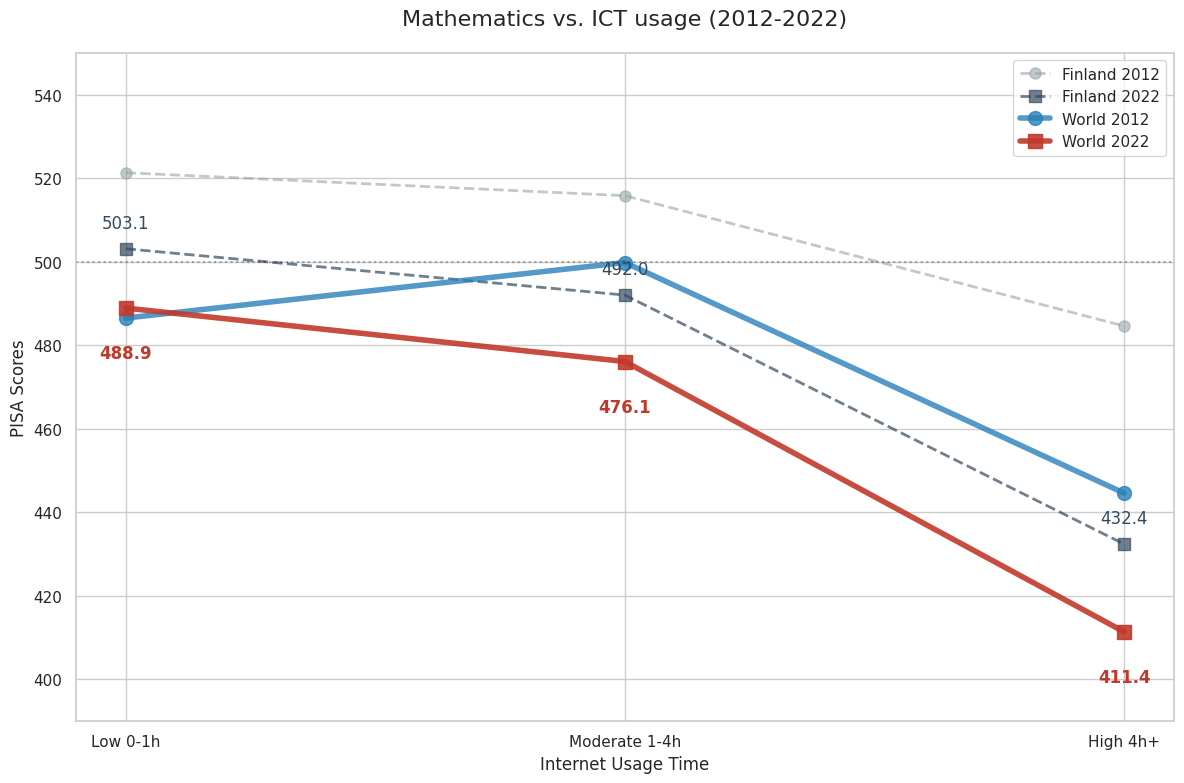

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA MATHEMATICS ---
usage_labels = ['Low 0-1h', 'Moderate 1-4h', 'High 4h+']

# Finnish results
fin_2012 = [521.3, 515.8, 484.6]
fin_2022 = [503.1, 492.0, 432.4]

# Global results
glob_2012 = [486.5, 499.8, 444.6]
glob_2022 = [488.9, 476.1, 411.4]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")


plt.plot(usage_labels, fin_2012, marker='o', markersize=8, linewidth=2, linestyle='--',
         color='#95a5a6', label='Finland 2012', alpha=0.6)
plt.plot(usage_labels, fin_2022, marker='s', markersize=8, linewidth=2, linestyle='--',
         color='#34495e', label='Finland 2022', alpha=0.7) 


plt.plot(usage_labels, glob_2012, marker='o', markersize=10, linewidth=4, color='#2980b9', label='World 2012', alpha=0.8) #2980b9
plt.plot(usage_labels, glob_2022, marker='s', markersize=10, linewidth=4, color='#c0392b', label='World 2022', alpha=0.9)


for i, val in enumerate(fin_2022):
    plt.text(i, val + 5, f'{val}', ha='center', color='#34495e') 
for i, val in enumerate(glob_2022):
    plt.text(i, val - 12, f'{val}', ha='center', color='#c0392b', fontweight='bold')


plt.title('Mathematics vs. ICT usage (2012-2022)', fontsize=16, pad=20)
plt.ylabel('PISA Scores', fontsize=12)
plt.xlabel('Internet Usage Time', fontsize=12)
plt.ylim(390, 550)
plt.legend(loc='upper right', fontsize=11)
plt.axhline(500, color='black', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

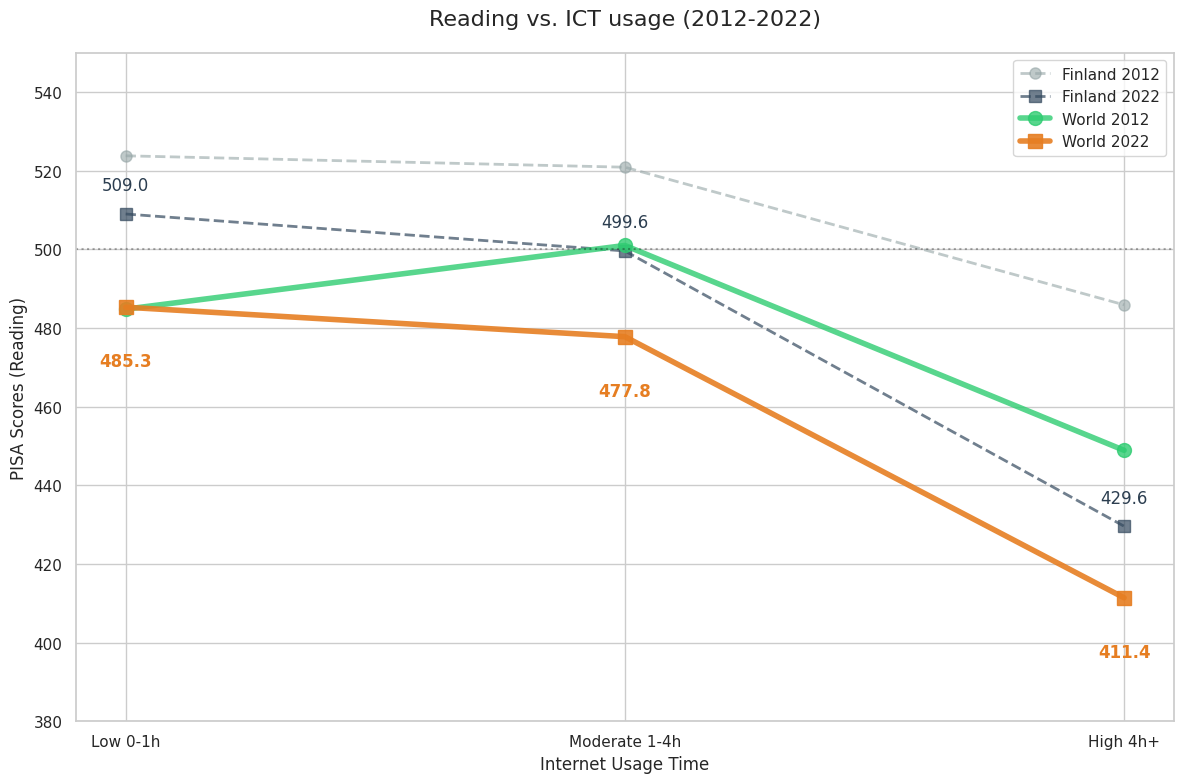

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA READING ---
usage_labels = ['Low 0-1h', 'Moderate 1-4h', 'High 4h+']

# Finnish results (Reading)
fin_read_2012 = [523.8, 520.9, 485.9]
fin_read_2022 = [509.0, 499.6, 429.6]

# Global results (Reading)
glob_read_2012 = [484.8, 501.0, 448.9]
glob_read_2022 = [485.3, 477.8, 411.4]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")


plt.plot(usage_labels, fin_read_2012, marker='o', markersize=8, linewidth=2, linestyle='--',
         color='#95a5a6', label='Finland 2012', alpha=0.6)
plt.plot(usage_labels, fin_read_2022, marker='s', markersize=8, linewidth=2, linestyle='--',
         color='#34495e', label='Finland 2022', alpha=0.7) 


plt.plot(usage_labels, glob_read_2012, marker='o', markersize=10, linewidth=4, color='#2ecc71', label='World 2012', alpha=0.8) 
plt.plot(usage_labels, glob_read_2022, marker='s', markersize=10, linewidth=4, color='#e67e22', label='World 2022', alpha=0.9)


for i, val in enumerate(fin_read_2022):
    plt.text(i, val + 6, f'{val}', ha='center', color='#2c3e50') 
for i, val in enumerate(glob_read_2022):
    plt.text(i, val - 15, f'{val}', ha='center', color='#e67e22', fontweight='bold')

# Muotoilu
plt.title('Reading vs. ICT usage (2012-2022)', fontsize=16, pad=20)
plt.ylabel('PISA Scores (Reading)', fontsize=12)
plt.xlabel('Internet Usage Time', fontsize=12)
plt.ylim(380, 550)
plt.legend(loc='upper right', fontsize=11)
plt.axhline(500, color='black', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()